# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `Thi Ha Giang Nguyen (Jana)`  
**SFU ID:** `301541572`  
**Date:** `[Submission Date]`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [2]:
df_ab = pd.read_csv('phigma_ab_study.csv', keep_default_na = False)

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                 object
ab_group                                object
device_type                             object
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                             object
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NA,5,1,1,0,38,17.91


In [3]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,U10149,control,desktop,NaN,NaN,NA,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,677,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [4]:
# Missing values
df_ab.isnull().sum()


user_id                                0
ab_group                               0
device_type                            0
account_age_days                       0
prior_whiteboard_sessions              0
plan_region                            0
num_collaborators                      0
feature_tour_completed                 0
templates_used                         0
ai_suggestions_used                    0
whiteboard_actions_per_session         0
avg_whiteboard_session_duration_min    0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


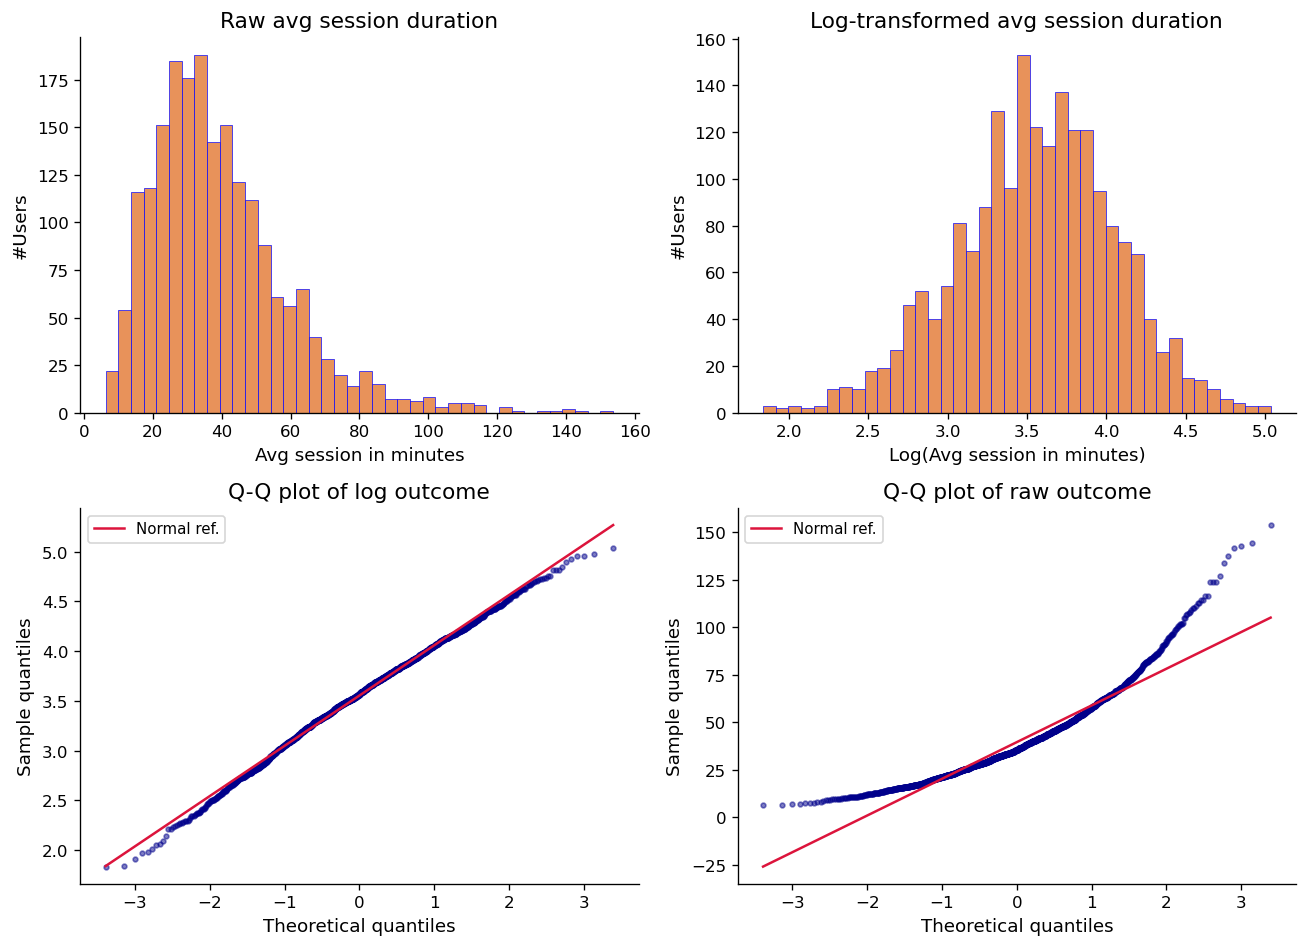

Skewness - raw outcome : 1.3768
Skewness - log outcome : -0.2135
(Rz of Q-Q fit) : 0.9969


In [5]:
# BEGIN
#     Load target outcome variable

#     // 1. Normality & Transformation Visualizations
#     Initialize three-panel visual layout
    
#     Draw histogram of raw outcome distribution
#     Transform outcome variable using natural logarithm
#     Draw histogram of log-transformed outcome distribution
#     Draw Q-Q plot comparing log-transformed distribution to a normal distribution
    
#     Render visualizations

#     // 2. Statistical Diagnostics
#     Compute and output skewness for both raw and log-transformed distributions
# END

y_raw = df_ab['avg_whiteboard_session_duration_min']
y_log = np.log(y_raw)

fig, axes = plt.subplots(2,2, figsize=(11,8))

# Raw data frame
axes[0,0].hist(y_raw, bins=40, color=ACCENT, edgecolor='blue', linewidth=0.4)  
axes[0,0].set_title("Raw avg session duration")
axes[0,0].set_xlabel("Avg session in minutes")
axes[0,0].set_ylabel("#Users")

# log transformed
axes[0,1].hist(y_log, bins=40, color=ACCENT, edgecolor='blue', linewidth=0.4) 
axes[0,1].set_title("Log-transformed avg session duration")
axes[0,1].set_xlabel("Log(Avg session in minutes)")  
axes[0,1].set_ylabel("#Users")

# Q-Q plot of log outcome
(osm, osr), (slope, intercept, r) = stats.probplot(y_log, dist="norm")
axes[1,0].scatter(osm, osr, color="darkblue", s=8, alpha=0.5) 
axes[1,0].plot(osm, slope * np.array(osm) + intercept, color="crimson", lw=1.5, label="Normal ref.") 
axes[1,0].set_title("Q-Q plot of log outcome")
axes[1,0].set_xlabel("Theoretical quantiles")
axes[1,0].set_ylabel("Sample quantiles")  
axes[1,0].legend(fontsize=9)

# Q-Q plot of raw outcome
(osm_r, osr_r), (slope_r, intercept_r, r_raw) = stats.probplot(y_raw, dist="norm")
axes[1,1].scatter(osm_r, osr_r, color="darkblue", s=8, alpha=0.5)
axes[1,1].plot(osm_r, slope_r * np.array(osm_r) + intercept_r, color="crimson", lw=1.5, label="Normal ref.")
axes[1,1].set_title("Q-Q plot of raw outcome")
axes[1,1].set_xlabel("Theoretical quantiles")
axes[1,1].set_ylabel("Sample quantiles")
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()

skew_raw = float(y_raw.skew())
skew_log = float(y_log.skew())
print(f"Skewness - raw outcome : {skew_raw:.4f}")
print(f"Skewness - log outcome : {skew_log:.4f}")
print(f"(Rz of Q-Q fit) : {r**2:.4f}")


#### A1.2 — Examine the confounders

**✏️ Your interpretation (A1.1):**

*Replace this text. Is the log-transformed outcome more normally distributed? How does the Q-Q plot support your conclusion? Will you use the raw or log outcome in your model?*

Yes the log-transformed out come more normmally distributed. If we look at the Q-Q plot, if the data were normal then the points would sit on the straight reference line. For the raw outcome, the points clearly move away from the line in the upper right which is the signature of a heavy right tail. For the log outcome, the points hug the line across almost the whole range with only small wiggles at the very ends.

Also worth to mention that the skewness raw outcome and log outcome also tell the same as the raw outcome has skew = 1.38 which is strong right skew. While a normal distribution has skew = 0. After taking the log, the skew drops to -0.21. SO the log does work cause it compresses big values more than small values so it pulls that long right tail back in.  

So yea cause all of this I will use the log outcome in my model.



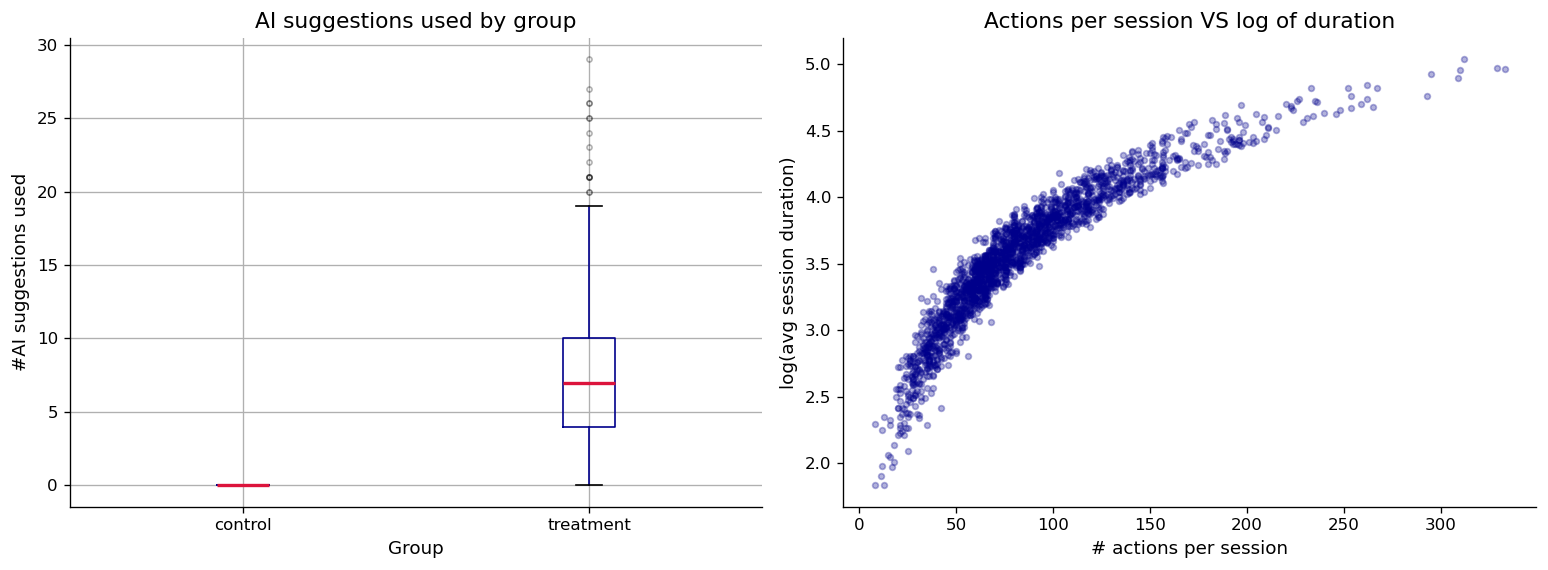

Pearson r (whiteboard_actions_per_session vs log_duration) : 0.9136

Descriptive stats for ai_suggestion_used by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [6]:
# // Define the analytical pipeline
# BEGIN
#     Load AB testing dataset

#     // 1. Visual Exploratory Data Analysis
#     Initialize side-by-side visualization layouts
    
#     Draw boxplot comparison of AI suggestion usage across experimental groups
#     Draw scatter plot comparing whiteboard activity density against session durations
    
#     Optimize layout and display visualizations

#     // 2. Statistical Analysis
#     Calculate and print the correlation between whiteboard activity and session duration
#     Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
# END

fig, axes = plt.subplots(1,2, figsize = (13,5))

df_ab.boxplot(column = "ai_suggestions_used", by = "ab_group", ax= axes[0],
                boxprops = dict(color = "darkblue"), 
                medianprops = dict(color = "crimson", lw =2), 
                whiskerprops = dict(color="darkblue"),  
                capprops = dict(color = "black"),
                flierprops = dict(marker="o", color ="blue", alpha=0.3, markersize=3)
              )
axes[0].set_xlabel("Group")
axes[0].set_title("AI suggestion used by exp group")
axes[0].set_ylabel("#AI suggestions used")
plt.sca(axes[0])
plt.title("AI suggestions used by group")
plt.suptitle('')  

log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])
axes[1].scatter(df_ab['whiteboard_actions_per_session'], log_dur, color = "darkblue",
                alpha= 0.3, s = 12)
axes[1].set_xlabel("# actions per session")
axes[1].set_title("Actions per session VS log of duration")
axes[1].set_ylabel("log(avg session duration)")

plt.tight_layout()
plt.show()

corr_actions = df_ab["whiteboard_actions_per_session"].corr(log_dur)
print(f"Pearson r (whiteboard_actions_per_session vs log_duration) : {corr_actions:.4f}")

print("\nDescriptive stats for ai_suggestion_used by group:")
print(df_ab.groupby("ab_group") ["ai_suggestions_used"].describe().round(2))

**✏️ Your interpretation (A1.2):**

*Replace this text. What do you notice about `ai_suggestions_used` across the two groups? What does the correlation between `whiteboard_actions_per_session` and the outcome suggest? Why should neither be included in your model?*

As we can see in the descriptive stats the control has count 1011 with mean, min, max all 0. While treatment has mean 7.33, median 7, and max 29. This tells us the control users couldnt use AI suggestions cause they had no access to AI. The variable is a consequence of group assignment not a pre existing user trait so this is a pots-treatment variable.

whiteboard_actions_per_session correlates at r = ~0.91 with log duration and scatter shows a tight band with almost no cloud around it. Real behavioural predictors dont correlate at 0.91 with an outcome, this variable is essentially a second measurement of session duration as longer sessions mechanically contain more actions. It is also measured during the same experiment window as the outcome, not before it.

So from all of this, neither should be included in my model cause including ai_suggestions_used would strip out the pathway the assistant worls through so the ab_group coef would shrink toward zero and we would wrongly conclude the assistant does little. While the whiteboard_actions_per_session would inflate R2 while making every other coef, including treatment, meaningless as we would be explaining duration with duration. Also only pre-treatment covariates + the randomized group indicator belong in the causal model.


#### A1.3 — Predictor distributions and relationships with outcome

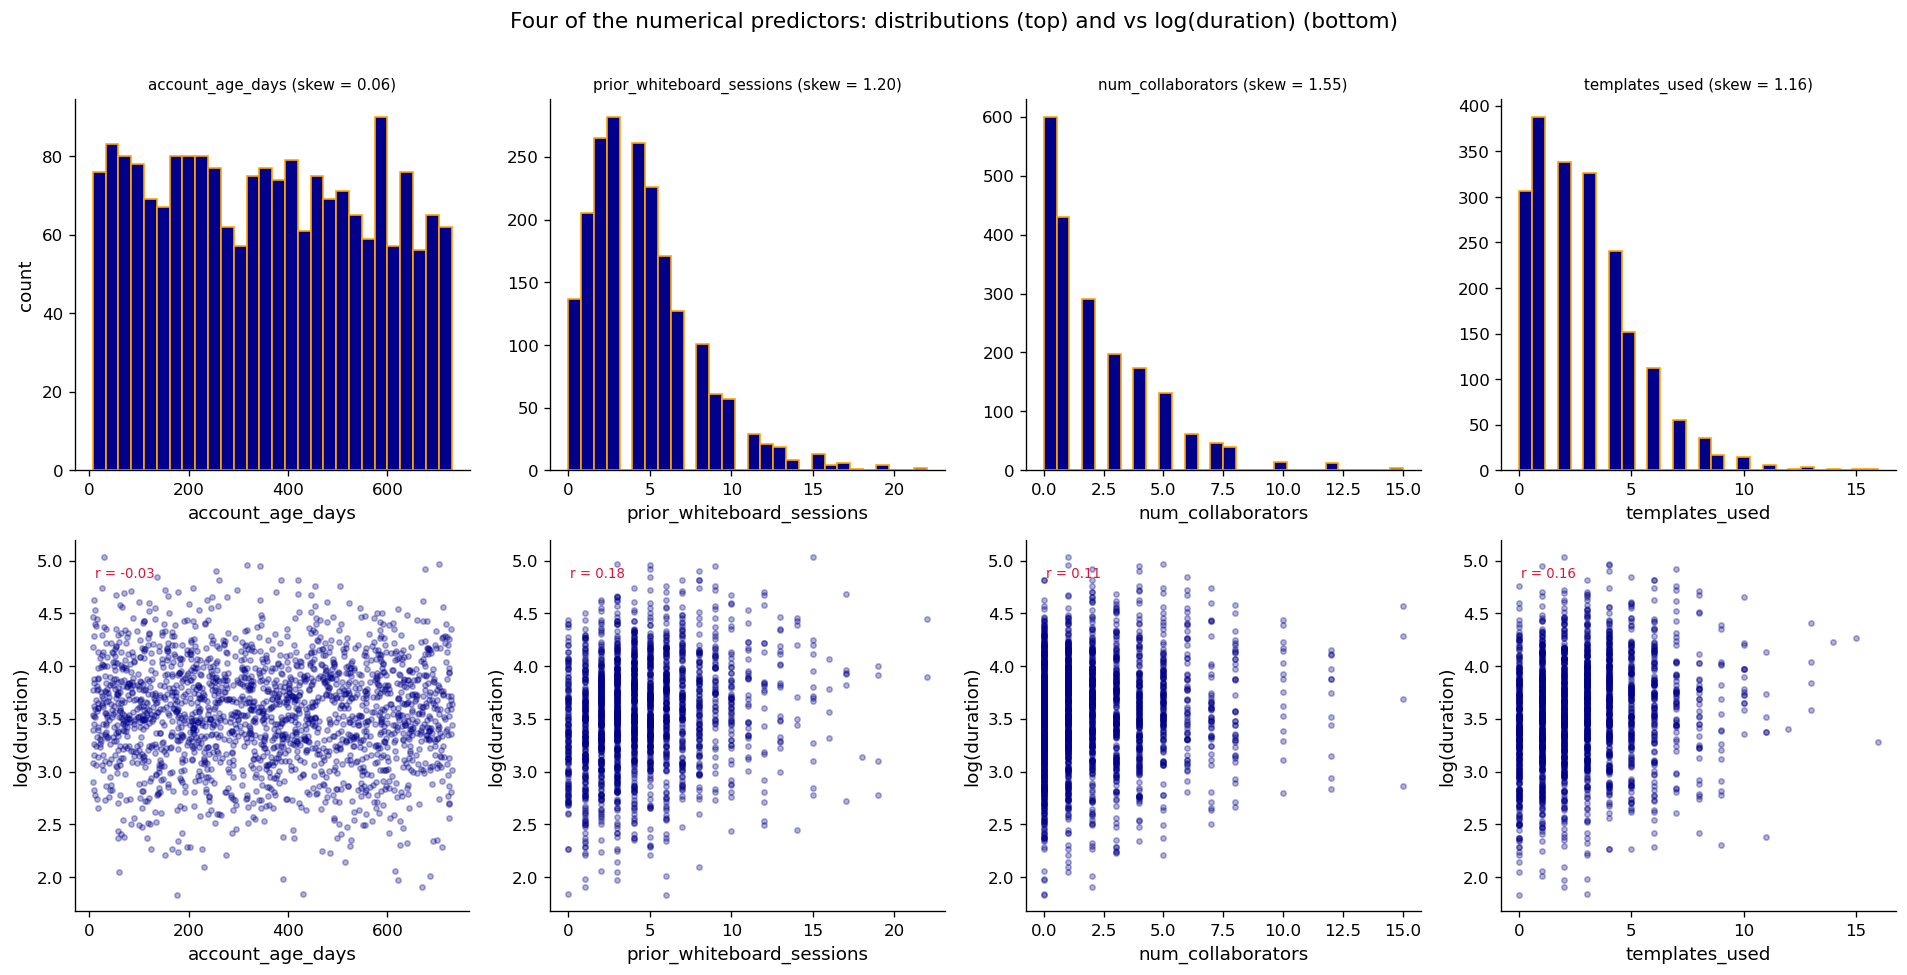

In [7]:
# BEGIN
#     Define list of numerical predictor variables
#     Compute log-transformed outcome variable

#     Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)

#     FOR each predictor variable:
#         // Top row: Univariate Analysis
#         Draw histogram to show distribution of the predictor
        
#         // Bottom row: Bivariate Analysis
#         Draw scatter plot comparing predictor against log-transformed outcome
#         Calculate correlation coefficient between predictor and log-transformed outcome
#         Annotate plot with correlation coefficient
#     END FOR

#     Add global title and render layout
# END

num_predictors = [
    "account_age_days",
    "prior_whiteboard_sessions",
    "num_collaborators",
    "templates_used"
]

n = len(num_predictors)
fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
fig.suptitle("Four of the numerical predictors: distributions (top) and vs log(duration) (bottom)",
             fontsize = 13, y = 1.01)

for j, col in enumerate(num_predictors):

    #top row: histogram
    axes[0, j].hist(df_ab[col], bins = 28, color="darkblue", edgecolor="orange", lw="0.4")
    axes[0, j].set_title(f"{col} (skew = {df_ab[col].skew():.2f})", fontsize=9)
    axes[0, j].set_xlabel(col)
    axes[0, j].set_ylabel("count" if j == 0 else "")

    #bottom row: scatterplot
    r = df_ab[col].corr(log_dur)
    axes[1, j].scatter(df_ab[col], log_dur, color ="darkblue", alpha =0.3, s = 10)
    axes[1, j].set_xlabel(col)
    axes[1, j].set_ylabel("log(duration)")
    axes[1, j].annotate(f"r = {r:.2f}", xy = (0.05, 0.9), xycoords="axes fraction", fontsize=8, color="crimson")

plt.tight_layout()
plt.show()

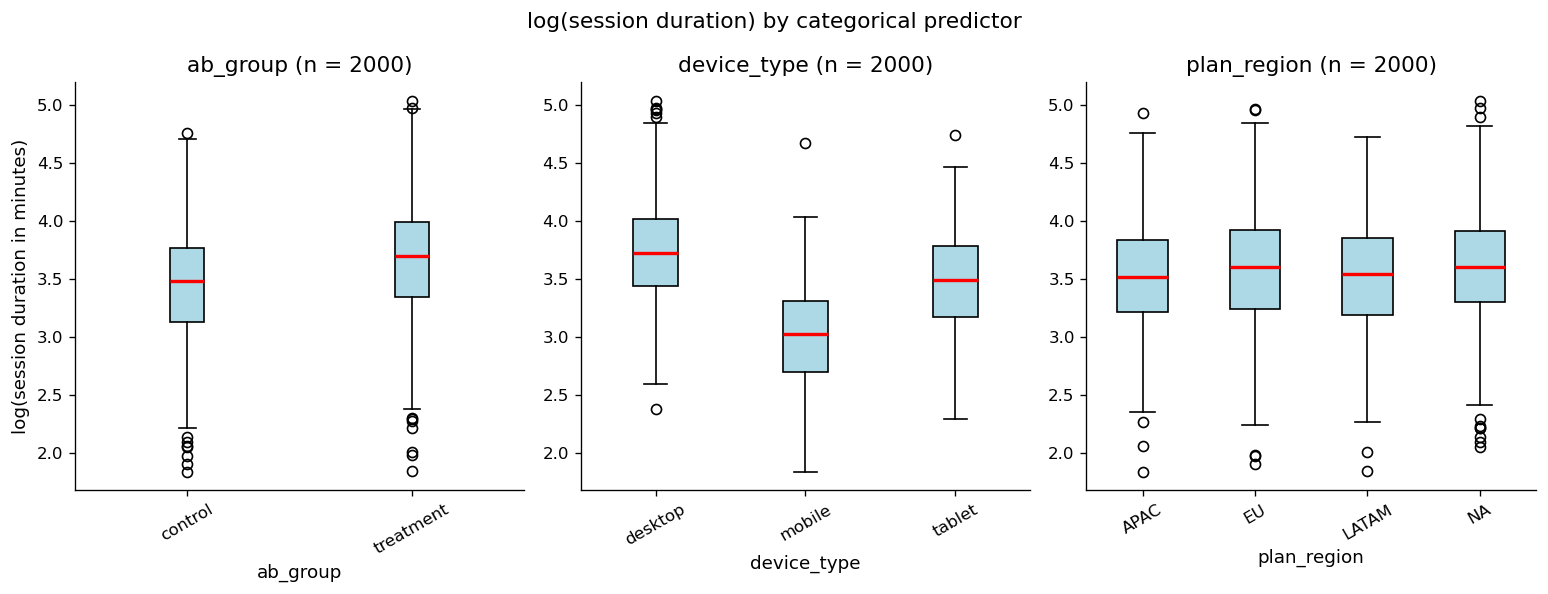

In [8]:
# BEGIN
#     Define list of categorical predictor variables
#     Initialize visual grid layout (1 row by N columns, where N is the number of categories)

#     FOR each categorical variable:
#         Retrieve unique category levels
        
#         Group log-transformed outcome values by category levels
        
#         Draw boxplots of log-transformed outcome grouped by category level
#         Rotate category axis labels for readability
        
#         Label axis and set titles
#     END FOR

#     Render layout
# END

cat_predictors = ['ab_group', 'device_type', 'plan_region']
fig, axes = plt.subplots(1, len(cat_predictors), figsize = (13,5))
fig.suptitle('log(session duration) by categorical predictor', fontsize = 13)

for j, col in enumerate(cat_predictors):
    levels = sorted(df_ab[col].dropna().unique())
    grouped = [log_dur[df_ab[col] == lvl].values for lvl in levels]
    axes[j].boxplot(grouped, tick_labels=levels, patch_artist=True, boxprops=dict(facecolor="lightblue"), medianprops=dict(color="red", lw=2))
    axes[j].set_title(f"{col} (n = {df_ab[col].notna().sum()})")
    axes[j].set_xlabel(col)
    axes[j].set_ylabel("log(session duration in minutes)" if j == 0 else '')
    axes[j].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
    

**✏️ Your interpretation (A1.3):**

*3–5 sentences summarizing your EDA. Which predictors look most promising? Are any right-skewed and worth log-transforming before use as predictors? Which two features are you excluding and why?*

SO we can see prior_whiteboard_sessions looks the most promising as it has r = +0.18 with log duration. templates_used (r = +0.16) and num_collaborators (r = +0.11) are also promising but def not account_age_days as it is basically flat (r = -0.03) so it carries almost no signal about how long people spend in a session. 

On the categorical side the device_type boxplots show the clearest separation, desktop sits well above mobile, so device is going to matter a lot in the model.

The num predictors mostly show mild to moderate right skew. account_age_days (skew = 0.06) is basically flat while prior_whiteboard_sessions (skew = 1.20), num_collaborators (skew = 1.55) and templates_used (skew = 1.16) all have long right tails, so the skewed ones are definitely worth log transforming before going into the model. 

For exclusions, on top of ai_suggestions_used and whiteboard_actions_per_session (cause they are both post-treatment), templates_used is also measured during the experiment window per the data dictionary, so it is a third post-treatment variable. Even though it correlate a bit with the outcome, I keep it out of the causal model, cause anything measured after randomization can be affected by the treatment and would bias the ab_group estimate.

### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [9]:
# BEGIN
#     Load baseline dataset

#     // 1. Encode Categorical Variables
#     Convert experimental group ('ab_group') into a binary integer indicator
#     Generate dummy indicators (one-hot encoding) for device types, omitting the first category
#     Generate dummy indicators (one-hot encoding) for regions, omitting the first category

#     // 2. Perform Optional Transformations
#     Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values

#     // 3. Assemble Modeling Dataset
#     Merge numerical characteristics, binary groups, and dummy indicators into matrix X
#     Set target vector y as the log-transformed outcome variable

#     // 4. Quality Control
#     Verify that there are no missing (null) values in feature matrix X
#     Inspect matrix dimensions and print a preview of the processed data
# END

df_ab['ab_group_enc'] = (df_ab['ab_group'] == 'treatment').astype(int)
device_dummies = pd.get_dummies(df_ab['device_type'], prefix = "device", drop_first = True).astype(int)
region_dummies = pd.get_dummies(df_ab['plan_region'], prefix = "region", drop_first = True).astype(int)

log_account_age = np.log1p(df_ab["account_age_days"])
log_prior_whiteboard_sessions = np.log1p(df_ab["prior_whiteboard_sessions"])
log_num_collaborators = np.log1p(df_ab["num_collaborators"])

X = pd.concat([
    df_ab["ab_group_enc"].rename("ab_group"),
    log_account_age.rename("log_account_age_days"),
    log_prior_whiteboard_sessions.rename("log_whiteboard_sessions"),
    log_num_collaborators.rename("log_num_collaborators"),
    device_dummies,
    region_dummies
], axis = 1)

y = np.log(df_ab["avg_whiteboard_session_duration_min"])

# Fixed: Now using consistent variable name 'X' (uppercase)
assert X.isnull().sum().sum() == 0
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"\nFeature columns:\n{X.columns.tolist()}")
X.head(20)

#BEIGN I used AI in jupyter to fix the naming error
#CLOSE

Feature matrix shape: (2000, 9)
Missing values in X: 0

Feature columns:
['ab_group', 'log_account_age_days', 'log_whiteboard_sessions', 'log_num_collaborators', 'device_mobile', 'device_tablet', 'region_EU', 'region_LATAM', 'region_NA']


,ab_group,log_account_age_days,log_whiteboard_sessions,log_num_collaborators,device_mobile,device_tablet,region_EU,region_LATAM,region_NA
0,0,6.171701,1.609438,1.386294,0,1,1,0,0
1,0,6.452049,2.302585,0.693147,0,0,0,0,0
2,0,5.075174,2.397895,1.791759,0,0,0,0,1
3,0,2.079442,1.791759,0.693147,0,0,0,0,1
4,0,3.806662,1.386294,0.000000,1,0,0,0,1
5,1,6.400257,1.098612,0.000000,0,0,0,1,0
6,0,6.364751,1.945910,0.693147,0,1,1,0,0
7,0,5.488938,2.484907,1.386294,0,0,0,0,1
8,1,5.252273,2.708050,0.000000,0,0,0,0,0
9,0,6.498282,1.386294,1.098612,0,1,0,0,0


**✏️ Your interpretation (A2):**

*List your final features. For each one, write one sentence justifying its inclusion and any transformation applied.*

My final feature set is the randomized treatment indicator plus pre-treatment covariates only. So based on this we have:
- ab_group (0/1): this is the variable I actually care about, it just marks whether a user gets the AI (treatment) or not (control), and since it is randomly assigned it does not need any transform
- log_account_age_days: this is how long the account exists before the experiment, so it is a baseline measure of how established the user is, and I log it cause the raw days span a very wide range
- log_whiteboard_sessions: this is how many whiteboard sessions the user has before the experiment, which is a baseline for how active they've already are and it is my strongest numeric predictor, and I log it cause it is right skewed and has some zeros
- log_num_collaborators: this is the user's team size before the experiment, and I log it cause appeareatly it is right skewed with a lot of zeros 
- device_mobile, device_tablet: these are the one-hot columns for device_type with desktop dropped as the baseline, so each coef reads as that device compared to desktop
- region_EU, region_LATAM, region_NA: these are the one-hot columns for plan_region with APAC dropped as the baseline

I use log(x+1) instead of plain log(x) on the three count predictors cause they contain zeros, and plain log(0) is undefined so it would break the model, while log(x+1) safely turns a zero into a zero. I also deliberately drop ai_suggestions_used, whiteboard_actions_per_session and templates_used, cause all three are measured during the experiment window, which makes them post-treatment variables that would bias the treatment estimate. Lastly, the assert line confirms that there are no missing values anywhere in X.

### A3 — OLS Regression


In [10]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit(cov_type = "HC3")
print(model_ols.summary())


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.358
Model:                                             OLS   Adj. R-squared:                  0.355
Method:                                  Least Squares   F-statistic:                     111.6
Date:                                 Sun, 05 Jul 2026   Prob (F-statistic):          1.76e-169
Time:                                         21:46:20   Log-Likelihood:                -1028.8
No. Observations:                                 2000   AIC:                             2078.
Df Residuals:                                     1990   BIC:                             2134.
Df Model:                                            9                                         
Covariance Type:                                   HC3                                         
                              coef    st

#### A3.1 — Interpret the model

In [11]:
# BEGIN
#     Input trained OLS regression model
#     Input experimental dataframe

#     // 1. Evaluate Model Fit
#     Display model's R-squared value to assess variance explained

#     // 2. Analyze Treatment Effect
#     Extract coefficient and significance (p-value) for the A/B testing variable
#     Convert the log-space treatment coefficient back to its scale in physical time (minutes) 
#     Display treatment effect size and statistical significance

#     // 3. Extract Significant Predictors
#     Filter all model coefficients where p-value < 0.05
#     FOR each significant variable:
#         Display variable name, its directional coefficient, and its p-value
#     END FOR
# END

print(f"R² = {model_ols.rsquared:.4f}")
print(f"Adj. R² = {model_ols.rsquared_adj:.4f}")
print()

ab_coef = model_ols.params["ab_group"]
ab_pval = model_ols.pvalues["ab_group"]

ab_pct_change = (np.exp(ab_coef) - 1)

control_mean = df_ab.loc[df_ab["ab_group"] == "control", "avg_whiteboard_session_duration_min"].mean()

ab_mins_effect = control_mean * (np.exp(ab_coef) -1 )
print(f"ab_group coefficient : {ab_coef:.4f}")
print(f"p-value : {ab_pval:.4f}")
print(f"Back-transformed : {ab_pct_change*100:.1f}% relative to control mean")
print(f" : ~= {ab_mins_effect:.1f} min above control mean ({control_mean:.1f} min)")

sig = model_ols.pvalues[model_ols.pvalues < 0.05].sort_values()
print("significant predictors are: ")
for var, pv in sig.items():
    coef = model_ols.params[var]
    print(f". {var:<35s}. coef = {coef:.4f}. p={pv:.4f}")
                                 


R² = 0.3576
Adj. R² = 0.3547

ab_group coefficient : 0.2170
p-value : 0.0000
Back-transformed : 24.2% relative to control mean
 : ~= 8.5 min above control mean (35.2 min)
significant predictors are: 
. const                              . coef = 3.3722. p=0.0000
. device_mobile                      . coef = -0.7257. p=0.0000
. device_tablet                      . coef = -0.2579. p=0.0000
. ab_group                           . coef = 0.2170. p=0.0000
. log_whiteboard_sessions            . coef = 0.1407. p=0.0000
. log_num_collaborators              . coef = 0.0861. p=0.0000
. region_NA                          . coef = 0.0826. p=0.0003
. region_EU                          . coef = 0.0768. p=0.0017


**✏️ Results paragraph (A3):**

*Write a results paragraph as if reporting in a research paper. Include:*
- *The treatment effect estimate and its significance*
- *R² and what it tells you about model fit*
- *At least two other notable predictors and their direction*
- *Whether the AI assistant's effect is practically meaningful (not just statistically significant)*


Getting access to the AI design assistant leads to a clear increase in how long users spend in whiteboard sessions. In the OLS model on log duration with HC3 robust standard errors, the treatment coef is 0.217 with p < 0.001, which back-transforms to about a ~24% increase, or about +8.5 minutes on top of the 35.2 minute control mean. The model has an R2 of 0.358, so about 36% of the variation in log session duration is explained by the treatment plus the baseline covariates, which is a very reasonable fit for behavioural data with this few predictors. Two other predictors also stand out. One is device_mobile which has a big negative coefficient (-0.73, p <0.001), which means mobile users spend way less time per session than desktop users, and the other is log_whiteboard_sessions which is positive (+0.14, p <0.001), which means users who are already active before the experiment keep running longer sessions. On the region side, EU and NA users sit a little above the APAC baseline (both p < 0.01). So the main thing is that this is not just a p-value story, an extra eight and a half minutes on a 35 minute baseline is a big, practically meaningful change, so the AI assistant genuinely moves the needle rather than just nudging it.


#### A3.2 — Regression diagnostics

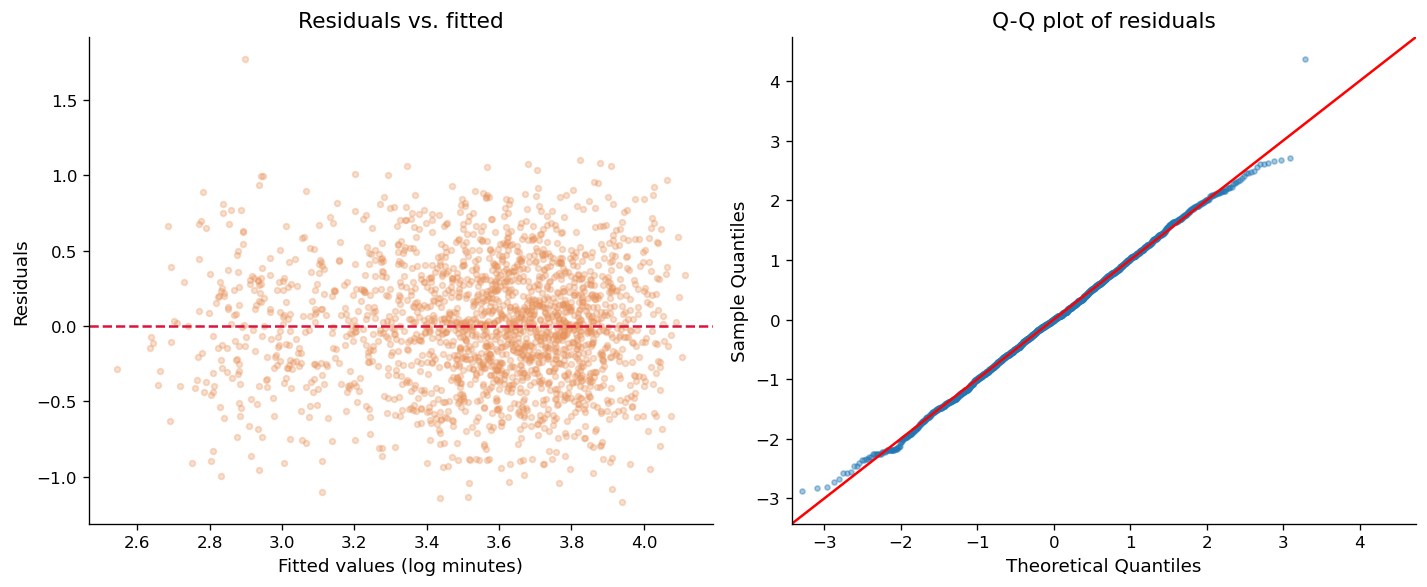

In [12]:
fitted = model_ols.fittedvalues
resid = model_ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted, resid, alpha=0.3, s=12, color=ACCENT)
axes[0].axhline(0, color='crimson', lw=1.5, linestyle='--')
axes[0].set_xlabel('Fitted values (log minutes)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. fitted')

sm.qqplot(resid, line='45', fit=True, ax=axes[1], markersize=3, alpha=0.4)
axes[1].set_title('Q-Q plot of residuals')

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A3.2):**

*Do the residuals look randomly scattered around zero? Does the Q-Q plot suggest normally distributed errors? Note any patterns that concern you.*

The residuals vs fitted plot looks like a fairly even band sitting around zero with no funnel shape, so the log transform do its job and the spread of the residuals stays roughly the same across the whole fitted range. The Q-Q plot of the residuals sits almost right on the 45 degree line with only tiny movement at the very ends, so the errors look close to normal. I already fit the model with HC3 robust standard errors as a backup, so even if there is a little non-constant variance I cannot spot by eye, my significance results are still safe. So nothing here really make me concern me, the log model is well behaved so yes I can trust the results.

### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*

I am testing the interaction ab_group and device_type (treatment crossed with what device the user is on).

My theoretical reason is that the AI assistant surfaces its suggestions in a side panel while the user works on the canvas, and that workflow needs screen real estate. On desktop there is enough space to read a suggestion and act on it without breaking flow, while on mobile and tablet the suggestion UI has to compete with the canvas, so acting on a suggestion is more friction and the assistant is harder to actually use. cause of that, I expect AI to pay off most where there is enough room for it, which will be desktop.

So since desktop is the dropped baseline, I set this up as two interaction terms, ab_group vs device_mobile and ab_group vs device_tablet, each read against desktop. My prediction the treatment effect will be larger for desktop users than for tablet/mobile users, so desktop is the group I expect to benefit most from the AI assistant.

In [13]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']

# Step 2: Add the interaction term to your feature matrix and refit OLS
# X_interact = pd.concat([X_const, interaction_col], axis=1)
# model_interact = sm.OLS(y, X_interact).fit()
# print(model_interact.summary())

df_ab['ab_x_device_mobile'] = df_ab['ab_group_enc'] * device_dummies['device_mobile']
df_ab['ab_x_device_tablet'] = df_ab['ab_group_enc'] * device_dummies['device_tablet']

X_interact = sm.add_constant(pd.concat([X, df_ab[['ab_x_device_mobile', 'ab_x_device_tablet']]], axis=1))
model_interact = sm.OLS(y, X_interact).fit(cov_type="HC3")
print(model_interact.summary())

print("\nkey terms (desktop is the baseline)")
print(f"ab_group (treatment effect for desktop) : coef = {model_interact.params['ab_group']:.4f}, p = {model_interact.pvalues['ab_group']:.4f}")
print(f"ab_x_device_mobile (mobile vs desktop) : coef = {model_interact.params['ab_x_device_mobile']:.4f}, p ={model_interact.pvalues['ab_x_device_mobile']:.4f}")
print(f"ab_x_device_tablet (tablet vs desktop) : coef = {model_interact.params['ab_x_device_tablet']:.4f}, p = {model_interact.pvalues['ab_x_device_tablet']:.4f}")


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.359
Model:                                             OLS   Adj. R-squared:                  0.355
Method:                                  Least Squares   F-statistic:                     91.50
Date:                                 Sun, 05 Jul 2026   Prob (F-statistic):          6.32e-168
Time:                                         21:46:20   Log-Likelihood:                -1027.4
No. Observations:                                 2000   AIC:                             2079.
Df Residuals:                                     1988   BIC:                             2146.
Df Model:                                           11                                         
Covariance Type:                                   HC3                                         
                              coef    st

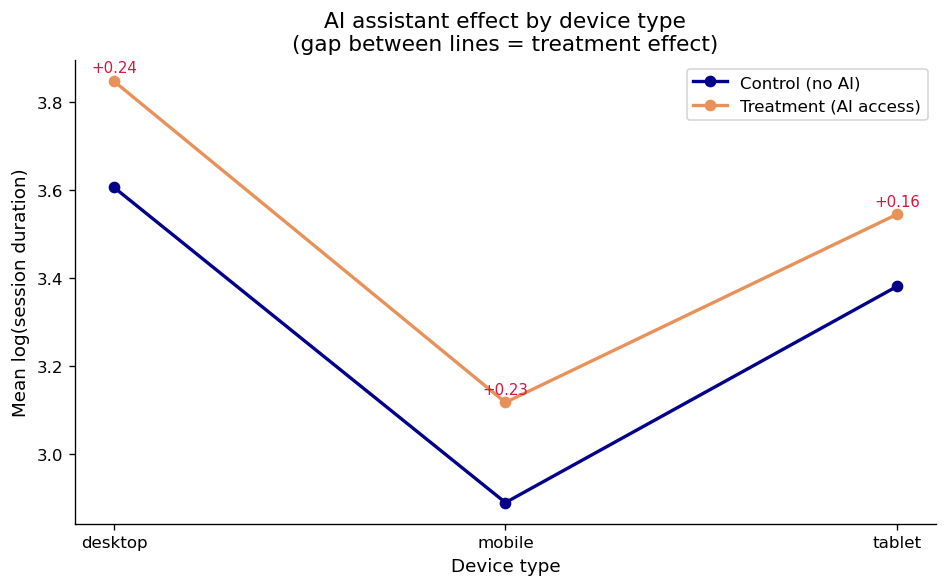

In [14]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines

grp = df_ab.groupby(['device_type', 'ab_group'], observed=True).apply(lambda d: np.log(d['avg_whiteboard_session_duration_min']).mean()
).unstack()
grp = grp.loc[['desktop', 'mobile', 'tablet']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grp.index, grp['control'], marker='o', color='darkblue', lw=2, label='Control (no AI)')
ax.plot(grp.index, grp['treatment'], marker='o', color=ACCENT, lw=2, label='Treatment (AI access)')

for i, dev in enumerate(grp.index):
    gap = grp.loc[dev, 'treatment'] - grp.loc[dev, 'control']
    ax.annotate(f"+{gap:.2f}", xy=(i, grp.loc[dev, 'treatment'] + 0.02), ha='center', fontsize=9, color='crimson')

ax.set_xlabel("Device type")
ax.set_ylabel("Mean log(session duration)")
ax.set_title("AI assistant effect by device type\n(gap between lines = treatment effect)")
ax.legend()

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*

Oh wait my hypothesis is actually weakly supported here. The direction goes the way I predict, both interaction coef come out negative like I expect (mobile and tablet get less out of the AI than the desktop baseline), and the plot shows the same story, desktop gets the biggest treatment gap at +0.24 log, tablet the smallest at +0.16, with mobile in between at +0.23. But neither interaction is significant at α =0.05, ab_x_device_tablet is -0.072 with p = 0.097 (the closest to significant) and ab_x_device_mobile is basically flat at -0.011 with p = 0.845.

So what the interaction coef tell me is that desktop users benefit most and tablet users least, which fits my screen-space reasoning, but the evidence is not strong enough to really call it a real effect. On the plot the treatment line sits above the control line by a similar amount on every device and the two lines stay roughly parallel rather than fanning out, which is what a null interaction looks like. The one term that even close with significance is tablet (p = 0.097), so if anything is real it is that tablet users get a slightly weaker boost, not that mobile does.

For Phigma (:>>) this means the screen-space worry does not really an issue, the AI assistant helps across all three device types at a broadly similar level. So they can roll it out on every device rather than gating it to desktop, and they do not need a separate desktop-only strategy. The only thing really worth watching is tablet, since it is the weakest of the three and the only interaction that comes close to significant, so it might be worth a closer look at how the suggestion UI behaves on tablet specifically.


---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [15]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                         object
signup_date                     object
first_session_date              object
device_type                     object
country_tier                    object
referral_source                 object
num_sessions_30d                 int64
total_time_min_30d               int64
projects_created_30d             int64
exports_30d                      int64
collaborators_invited_30d        int64
support_tickets_30d              int64
used_premium_feature_preview     int64
ai_assistant_sessions_30d        int64
subscribed                       int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [16]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [17]:
# YOUR CODE HERE

# 1. Parse dates
# df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
# df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
# df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
# df_sub['avg_session_duration_min'] = ...

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
# df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
# device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
# referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal): df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed
# X_sub = pd.concat([...], axis=1)
# y_sub = df_sub['subscribed']

# Confirm
# print(f"Any inf: {np.isinf(X_sub.values).any()}")
# print(f"Any NaN: {X_sub.isnull().any().any()}")
# print(f"Feature matrix shape: {X_sub.shape}")
# X_sub.head(3)


df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})

df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

df_sub['avg_session_duration_min'] = np.where(
    df_sub["num_sessions_30d"] == 0, 0,
    df_sub["total_time_min_30d"] / df_sub['num_sessions_30d']
)

df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

device_dummies = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True).astype(int)

referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True).astype(int)

df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})

raw_numeric = [
    "num_sessions_30d", "total_time_min_30d", "projects_created_30d",
    "exports_30d", "collaborators_invited_30d", "support_tickets_30d",
    "used_premium_feature_preview", "ai_assistant_sessions_30d"
]

engineered = [
    "days_to_first_session", "avg_session_duration_min", "is_weekend_signup",
    "country_tier_enc"
]

X_sub = pd.concat([df_sub[raw_numeric + engineered], device_dummies, referral_dummies ], axis=1)
y_sub = df_sub['subscribed']

numeric_cols = X_sub.select_dtypes(include=[np.number]).columns
print(f"Any inf: {np.isinf(X_sub[numeric_cols].values).any()}")  # Only check numeric columns
print(f"All numeric : {all(X_sub.dtypes != object)}")
print(f"Any NaN: {X_sub.isnull().any().any()}")
print(f"Feature matrix shape: {X_sub.shape}")
print(f"\nFeature names:\n{list(X_sub.columns)}")
X_sub.head(3)




Any inf: False
All numeric : True
Any NaN: False
Feature matrix shape: (3000, 17)

Feature names:
['num_sessions_30d', 'total_time_min_30d', 'projects_created_30d', 'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d', 'used_premium_feature_preview', 'ai_assistant_sessions_30d', 'days_to_first_session', 'avg_session_duration_min', 'is_weekend_signup', 'country_tier_enc', 'device_mobile', 'device_tablet', 'ref_paid_ad', 'ref_referral', 'ref_social']


,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,days_to_first_session,avg_session_duration_min,is_weekend_signup,country_tier_enc,device_mobile,device_tablet,ref_paid_ad,ref_referral,ref_social
0,1,96,1,0,0,0,1,6,5,96.0000,0,1,0,1,0,0,0
1,15,267,8,1,5,0,0,0,0,17.8000,0,2,0,1,0,0,1
2,16,263,0,0,3,3,1,4,14,16.4375,0,1,0,0,0,0,0


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*

- days_to_first_session: this is the gap between signing up and actually starting, and a long delay signals weak intent, so it should predict lower conversion.
- avg_session_duration_min: this is how deep each session is, and longer average sessions mean a more invested user who is more likely to pay.
- is_weekend_signup: this is a rough proxy for whether someone signs up in a personal or a work context, which can relate to how serious their intent is.
- device (mobile/tablet vs desktop): desktop users tend to do heavier design work, so device can help separate casual mobile try-ers from serious users.
- ref (paid_ad/referral/social vs organic): the channel a user arrives through carries intent, so someone who comes in through a referral is usually warmer than someone who just clicked a paid ad.
- country_tier_enc: this is the market wealth tier, which relates to how willing and able a user is to pay for a subscription.

I encode country_tier as ordinal (1/2/3) instead of one-hot, cause the tiers already have a real built-in order (tier_1 is the richest markets down to tier_3) so a single number captures that ranking, and it keeps the model leaner than spending three separate dummy columns on it. If the ordering did not match up with subscription behaviour I would switch to one-hot, but a natural rank like this is exactly the case where ordinal makes sense.

To handle divide-by-zero edge case, if num_sessions_30d = 0, total_time / sessions would be inf. I handle it with np.where, setting the value to 0 whenever num_sessions_30d is 0, since a user with no sessions has no meaningful average and 0 keeps them in the matrix without creating an inf or NaN. In this particular dataset the minimum is actually 1 session so the guard never fires, but it def makes the code safe and reproducible in case the data changes.


### B2 — EDA for Subscription


In [18]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


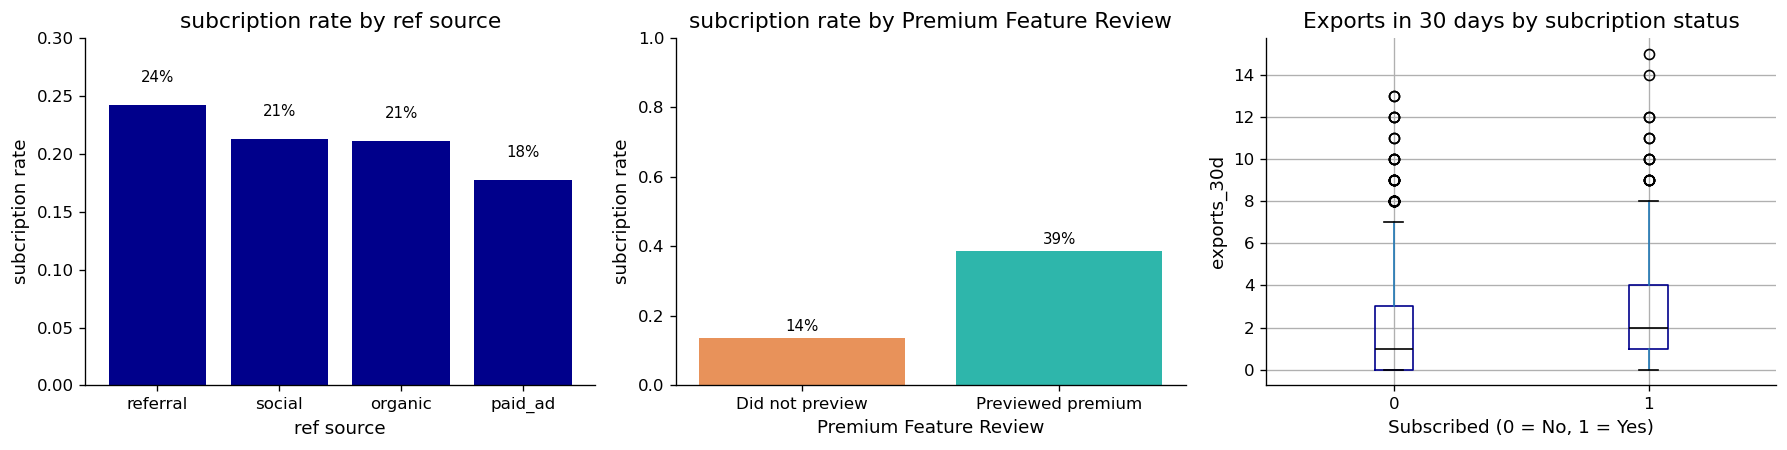

In [19]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sub_by_ref = df_sub.groupby("referral_source") ["subscribed"].mean().sort_values(ascending = False)
axes[0].bar(sub_by_ref.index, sub_by_ref.values, color = "darkblue")
axes[0].set_title("subcription rate by ref source")
axes[0].set_xlabel("ref source")
axes[0].set_ylabel("subcription rate")
axes[0].set_ylim(0,0.3)

for i , v in enumerate (sub_by_ref.values):
    axes[0].text(i, v + 0.02, f'{v:.0%}', ha = 'center', fontsize = 9)


sub_by_premium = df_sub.groupby("used_premium_feature_preview") ["subscribed"].mean()
labels = ["Did not preview", "Previewed premium"]
axes[1].bar(labels, sub_by_premium.values, color = [ACCENT, "#2eB6ab"])
axes[1].set_title("subcription rate by Premium Feature Review")
axes[1].set_xlabel("Premium Feature Review")
axes[1].set_ylabel("subcription rate")
axes[1].set_ylim(0,1)

for i , v in enumerate (sub_by_premium.values):
    axes[1].text(i, v + 0.02, f'{v:.0%}', ha = 'center', fontsize = 9)

df_sub.boxplot(column = "exports_30d", by = "subscribed", ax = axes[2], boxprops = dict(color="darkblue"), medianprops = dict(color="black"))
axes[2].set_title("Exports in 30 days by subcription status")
axes[2].set_xlabel("Subscribed (0 = No, 1 = Yes)")
axes[2].set_ylabel("exports_30d")
plt.suptitle("")

plt.tight_layout()
plt.show()


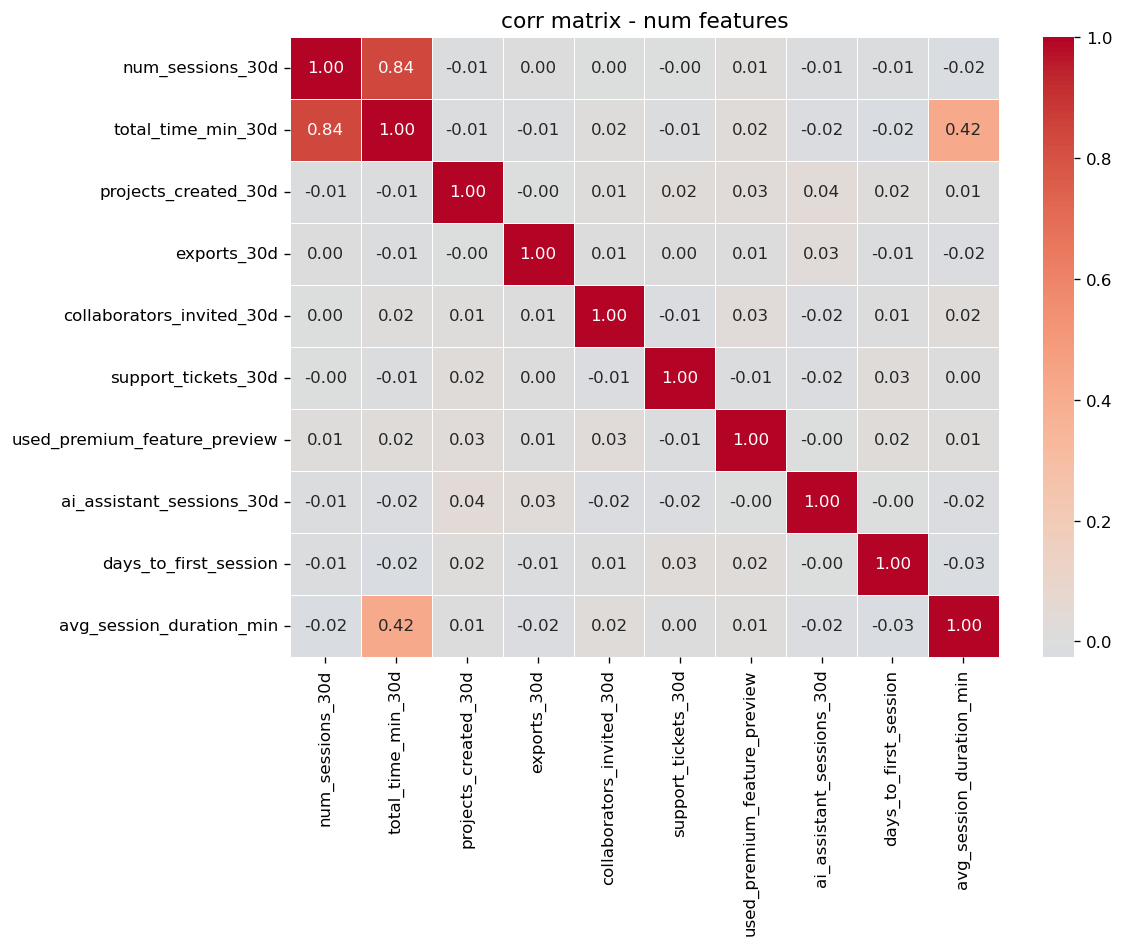

In [20]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
# numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
# corr = X_sub[numeric_features].corr()
# Plot as heatmap

numeric_features = [
    "num_sessions_30d", "total_time_min_30d", "projects_created_30d",
    "exports_30d", "collaborators_invited_30d", "support_tickets_30d",
    "used_premium_feature_preview", "ai_assistant_sessions_30d",
    "days_to_first_session", "avg_session_duration_min"
]

corr = X_sub[numeric_features].corr()

fig, ax = plt.subplots(figsize = (10,8))
sns.heatmap (
    corr,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    center = 0,
    ax = ax,
    linewidths = 0.35
)

ax.set_title("corr matrix - num features")
plt.tight_layout()
plt.show()


**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*

First, the dataset is imbalanced, only 20.8% of users subscribe, so the "subscribed" class is about 1 in 5 and the model is going to see a lot more non-subscribers than subscribers.

The features appear most strongly associated with subscription in my EDA are:
- used_premium_feature_preview: users who preview a paywalled feature subscribe at 39%, versus only 14% for users who do not. That is the biggest gap by far, so this looks like the strongest single signal.
- exports_30d: the boxplot shows subscribers have a higher median export count than non-subscribers, so people who export more tend to subscribe more.
- referral_source: there is a gap here too but it is small, referral is the highest at 24% and paid_ad the lowest at 18%, so the channel matters a bit but much less than the two behaviour features above.

Nothing here is really counterintuitive tho. If anything the small surprise is that referral_source matters less than I expected, the four channels are all close together (18% to 24%), so where a user comes from tells me a lot less than what they actually do inside the product.

For correlation, the one strong pair is num_sessions_30d and total_time_min_30d at r = 0.84, which actually makes sense cause more sessions means more total minutes. This concerns me a bit for the logistic model, since two features that carry almost the same information will split the shared signal between them and make each one's individual coef harder to trust. There is also a weaker link between total_time_min_30d and avg_session_duration_min at r =0.42, which is expected since one is built from the other but at 0.42 it is not strong enough to have to worry about.


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [21]:
X_const_sub = sm.add_constant(X_sub.astype(float))
model_logit = sm.Logit(y_sub, X_const_sub).fit()
print(model_logit.summary())


Optimization terminated successfully.
         Current function value: 0.440520
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2982
Method:                           MLE   Df Model:                           17
Date:                Sun, 05 Jul 2026   Pseudo R-squ.:                  0.1392
Time:                        21:46:20   Log-Likelihood:                -1321.6
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 3.542e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.5253      0.325     -7.772      0.000

In [22]:
odds_ratios = np.exp(model_logit.params)
conf_int    = np.exp(model_logit.conf_int())
conf_int.columns = ["OR_lower_95", "OR_upper_95"]

# Fixed DataFrame spelling and dictionary syntax
or_table = pd.DataFrame({
    "Odds Ratio": odds_ratios,  # Changed = to : for dictionary syntax
    "OR lower 95%": conf_int["OR_lower_95"],
    "OR upper 95%": conf_int["OR_upper_95"],  # Added missing closing quote
    "p-value": model_logit.pvalues
})

# Fixed column name quoting and added missing closing bracket
significants = or_table[
    (or_table["p-value"] < 0.05) & (or_table.index != "const")  # Added quotes around p-value and closing bracket
].sort_values("Odds Ratio", ascending=False)

print(significants.round(4).to_string())

#BEGIN I used AI in jupyter to fix the syntax errors
#CLOSE

                              Odds Ratio  OR lower 95%  OR upper 95%  p-value
used_premium_feature_preview      4.3470        3.5745        5.2864   0.0000
exports_30d                       1.2142        1.1633        1.2674   0.0000
support_tickets_30d               1.1673        1.0727        1.2702   0.0003
collaborators_invited_30d         1.0632        1.0178        1.1106   0.0059
avg_session_duration_min          1.0315        1.0112        1.0523   0.0023
days_to_first_session             0.9114        0.8872        0.9364   0.0000
country_tier_enc                  0.7001        0.6158        0.7959   0.0000


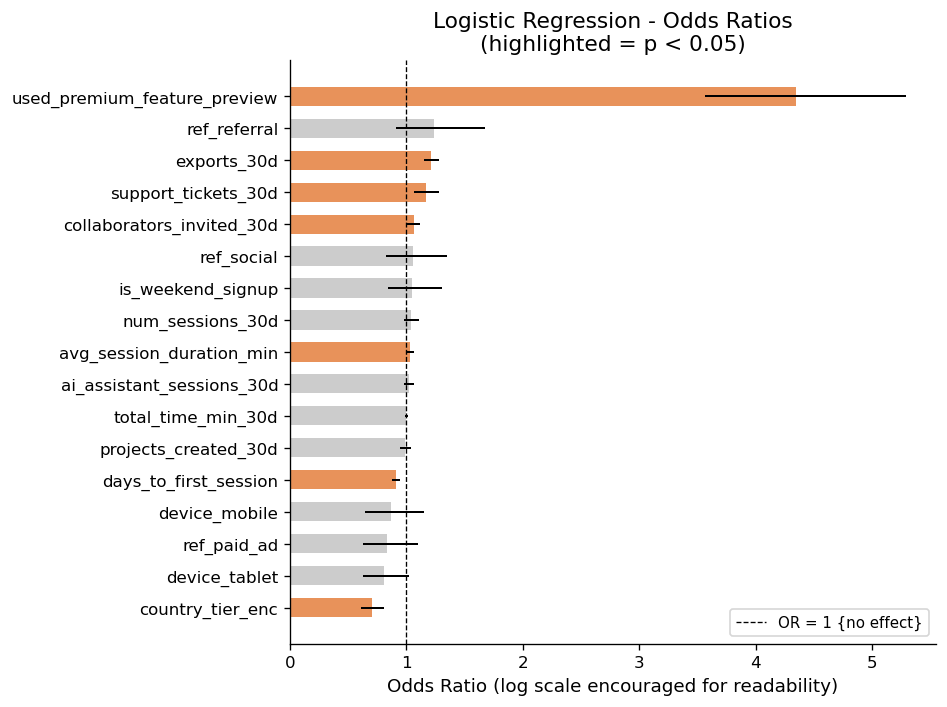

In [23]:
or_all = pd.DataFrame({
    "Odds Ratio": np.exp(model_logit.params),
    "lower": np.exp(model_logit.conf_int()[0]),
    "upper": np.exp(model_logit.conf_int()[1]),
    "p-value": model_logit.pvalues
}).drop("const").sort_values("Odds Ratio")

fig, ax = plt.subplots(figsize=(8,6))

colors = [ACCENT if p <0.05 else "#cccccc" for p in or_all ["p-value"]]

ax.barh(or_all.index, or_all["Odds Ratio"], color = colors, height = 0.6)

for i, (idx, row) in enumerate(or_all.iterrows()):
    ax.plot([row["lower"], row["upper"]], [i, i], color = "black", lw = 1.2)

ax.axvline(x = 1, color= "black", linestyle="--", lw= 0.8, label = "OR = 1 {no effect}")

ax.set_xlabel("Odds Ratio (log scale encouraged for readability)")
ax.set_title("Logistic Regression - Odds Ratios\n(highlighted = p < 0.05)")
ax.legend(fontsize = 9)
plt.tight_layout()
plt.show()


**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*

- used_premium_feature_preview (OR = 4.35): users who previewed a paywalled feature were about 4.3 times more likely to subscribe than users who did not, holding everything else constant
- exports_30d (OR = 1.21): users who exported one more file in their first 30 days were about ~21% more likely to subscribe, so users who export more tend to pay more
- support_tickets_30d (OR = 1.17): users who filed one more support ticket were about 17% more likely to subscribe

So the pattern is that in product behaviour predicts subscription much more strongly than things like device or ref channel, none of which come out significant.

The one finding that surprises me the most is support_tickets_30d (OR = 1.17, p < 0.001). Each support ticket a user files makes them about 17% more likely to subscribe. I expected support tickets to mean the user is frustrated and would be less likely to pay, but nope the data shows the abs opposite. My read is that filing a ticket is a sign of an active, invested user, not an unhappy one. These are people who are using the product enough to run into questions or hit the limits of the free tier, and that is exactly the kind of user who ends up subscribing.


### B4 — Logistic Regression with sklearn (Predictive)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
     X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


Train: (2400, 17)  |  Test: (600, 17)
Train positive rate: 0.208  |  Test positive rate: 0.208


In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_lr = LogisticRegression(max_iter = 1000, random_state = 42)
clf_lr.fit(X_train_scaled, y_train)

y_pred_lr = clf_lr.predict(X_test_scaled)
y_prob_lr = clf_lr.predict_proba(X_test_scaled)[:, 1]

print(f"{X_train_scaled.shape[0]}")
print(f"{X_test_scaled.shape[0]}")

2400
600


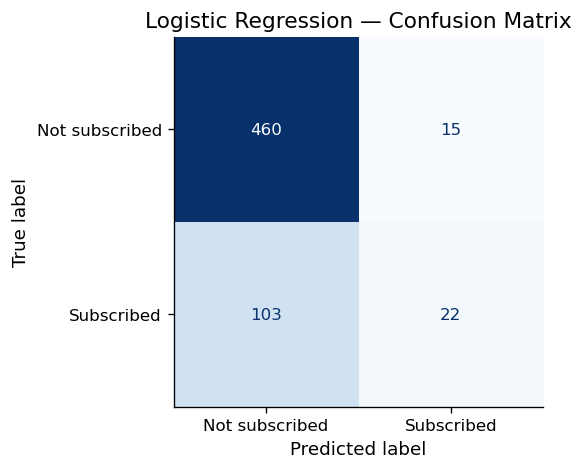

TN : 460
FP : 15
FN : 103
TP : 22
Accuracy : 0.8033333333333333
REcall : 0.176
Precision : 0.5945945945945946


In [26]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm_lr.ravel()

print(f"TN : {tn}")
print(f"FP : {fp}")
print(f"FN : {fn}")
print(f"TP : {tp}")

acc = (tn + tp) / 600
print(f"Accuracy : {acc}")
rec = tp / (tp+fn)
print(f"REcall : {rec}")
prec = tp /(tp+fp)
print(f"Precision : {prec}")


In [27]:
print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


                precision    recall  f1-score   support

Not subscribed       0.82      0.97      0.89       475
    Subscribed       0.59      0.18      0.27       125

      accuracy                           0.80       600
     macro avg       0.71      0.57      0.58       600
  weighted avg       0.77      0.80      0.76       600

ROC-AUC: 0.7373


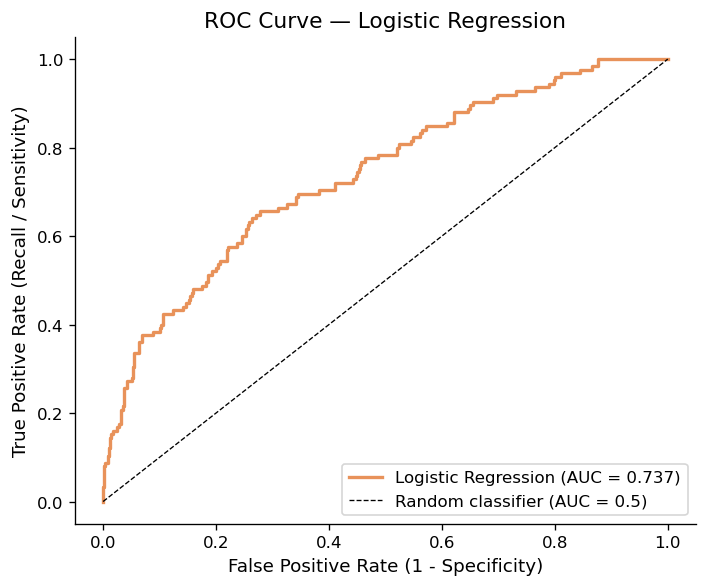

In [28]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8, label = "Random classifier (AUC = 0.5)")
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend(loc = "lower right")
plt.tight_layout()
plt.show()



**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*

Given the class imbalance, I think recall on the subscribed class is the most important metric, with ROC-AUC as a backup tho. Only about 20% of users subscribe, so accuracy is actually misleading here. A model that just predicts "nobody subscribes" would already get around 80% accuracy while being useless and my model's accuracy of 0.80 is basically that trap. What actually matters here to Phigma (:)) is to catch the users who do subscribe, and that is what recall measures. ROC-AUC (0.737) is also useful cause it judges how well the model ranks subscribers all above non-subscribers regardless of the imbalance.

After reading the confusion matrix we can see that the model gets 460 true negatives and 15 false positives, but only 22 true positives and 103 false negatives. So out of 125 real subscribers in the test set, the model only catches 22 and misses 103. That is a recall of just 0.18, so it finds fewer than 1 in 5 of the users who actually subscribe. Precision is higher at 0.59, which means when it does flag someone it is usually right, but it plays it way too safe and predicts "not subscribed" for almost everyone.

From Phigma's business perspective, each false negative is a user who would have subscribed but the model did not flag. That means these users never get the trial offer or upgrade prompt that could have pushed them to pay, so it is a lost revenue. Missing 103 out of 125 subscribers is a lot of lost conversions, so for a growth use case I would rather the model over-flags people (accept more false positives) than miss real subscribers like this. I would lower the decision threshold or add class weighting to trade some precision for much better recall.


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `Random Forest`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*

Random Forest learns by building a lot of separate decision trees, where each tree is trained on a different random sample of the training rows and only looks at a random subset of the features at each split. 

It tries to make for lower impurity, using Gini by default. Every tree splits the data on the feature that best separates subscribers from non-subscribers, and the forest's final prediction is the average of all the trees, which is what keeps it from overfitting on any single tree. 

This is structurally very different from logistic regression cause there is no single equation with one coef per feature, instead the forest cuts the feature space into boxes and can pick up non-linear patterns and interactions between features on its own. 

On this dataset that flexibility might actually work against it, since my B3 odds ratios suggest the real signal is mostly simple and monotonic (previewing a paid feature, exporting more, starting faster all push subscription steadily in one direction). Since the relationships look close to linear and the dataset is smallish and imbalanced, the forest could end up overfitting noise where logistic regression just fits the clean trend.



### C2 — Fit and Evaluate


In [29]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
# clf_c = YourModel(random_state=42)   # add random_state if supported
# clf_c.fit(X_train, y_train)
# y_pred_c = clf_c.predict(X_test)
# y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)

from sklearn.ensemble import RandomForestClassifier
clf_c = RandomForestClassifier(random_state = 42)   # default hyperparameters
clf_c.fit(X_train, y_train)

y_pred_c = clf_c.predict(X_test)
y_prob_c = clf_c.predict_proba(X_test)[:, 1]

print(f"Trees in forest : {clf_c.n_estimators}")
print(f"Trained on {X_train.shape[0]} rows, {X_train.shape[1]} features")


Trees in forest : 100
Trained on 2400 rows, 17 features


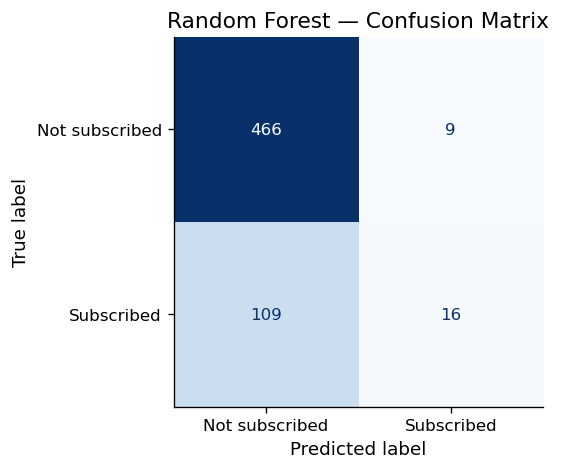

TN : 466
FP : 9
FN : 109
TP : 16


In [30]:
# YOUR CODE HERE
# Confusion matrix

cm_c = confusion_matrix(y_test, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_c, display_labels=['Not subscribed', 'Subscribed'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest — Confusion Matrix')
plt.show()

tn_c, fp_c, fn_c, tp_c = cm_c.ravel()
print(f"TN : {tn_c}")
print(f"FP : {fp_c}")
print(f"FN : {fn_c}")
print(f"TP : {tp_c}")

In [31]:
# YOUR CODE HERE
# Classification report + ROC-AUC

print(classification_report(y_test, y_pred_c, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_c):.4f}")

                precision    recall  f1-score   support

Not subscribed       0.81      0.98      0.89       475
    Subscribed       0.64      0.13      0.21       125

      accuracy                           0.80       600
     macro avg       0.73      0.55      0.55       600
  weighted avg       0.77      0.80      0.75       600

ROC-AUC: 0.6476


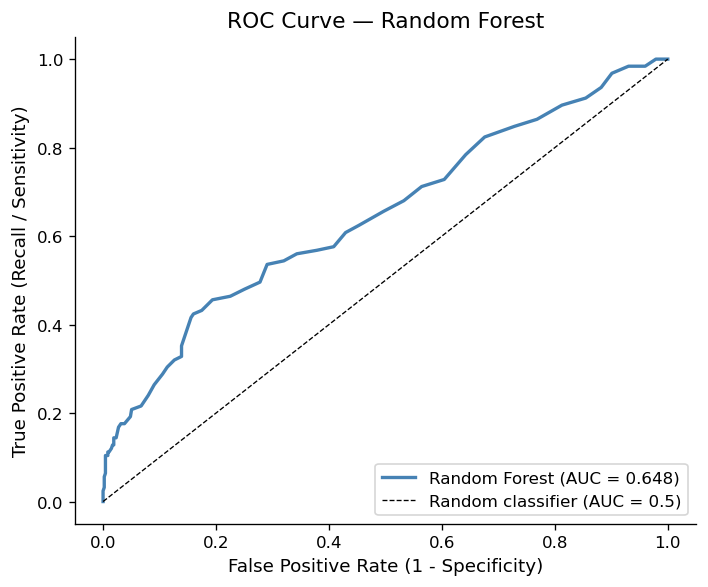

In [32]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)

fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)
auc_c = roc_auc_score(y_test, y_prob_c)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'Random Forest (AUC = {auc_c:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8, label = "Random classifier (AUC = 0.5)")
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax.set_title('ROC Curve — Random Forest')
ax.legend(loc = "lower right")
plt.tight_layout()
plt.show()

### C3 — Model Comparison


In [33]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)

from sklearn.metrics import f1_score, precision_score, recall_score

# BEGIN ChatGPT what is the syxtax of these metrics so I can fill in
metrics = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [auc_lr, auc_c],
    'F1 (class 1)': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_c)],
    'Precision (class 1)': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_c)],
    'Recall (class 1)': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_c)],
}
# END
pd.DataFrame(metrics).set_index('Model').round(4)


,ROC-AUC,F1 (class 1),Precision (class 1),Recall (class 1)
Model,,,,
Logistic Regression,0.7373,0.2716,0.5946,0.176
Random Forest,0.6476,0.2133,0.6400,0.128


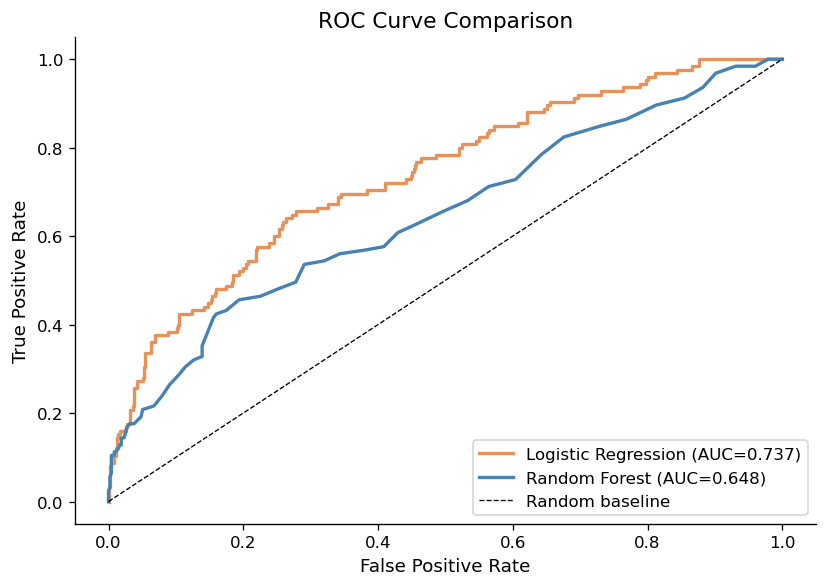

In [34]:
# YOUR CODE HERE
# Dual ROC curve plot
# fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
# ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'YOUR MODEL (AUC={auc_c:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve Comparison')
# ax.legend()
# plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'Random Forest (AUC={auc_c:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc = "lower right")
plt.tight_layout()
plt.show()

#BEGIN I used AI in the jupyter to fix the comma, (), etc
#CLOSE

**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*

Logistic regression wins. Its AUC is 0.737 versus ~0.648 for the default Random Forest, so a gap of about ~0.09, and it also beats the forest on F1 (0.27 vs 0.21) and recall (0.18 vs 0.13). The random forest only wins slightly on precision (0.64 vs 0.5946), and that's because it is even more careful about predicting "subscribed." The dual ROC plot shows the logistic curve sitting above the forest curve across almost the whole range, so this is not a threshold problem, the forest simply ranks users worse.

And I think there are three reasons to explain why this happens.

First, the relationships in this data are mostly simple and go in one steady direction. I saw this in B3 that more exports, faster activation, and previewing a paid feature each push the odds of subscribing up in a smooth, one-way manner. That is exactly the kind of pattern logistic regression is built for, so the forest's main strength (finding non-linear patterns and interactions on its own) does not help here, cause there are not really any to find.

Second, the default random forest overfits on this data. With max_depth set to None, each tree keeps splitting until its leaves are almost pure, and on 2400 training rows with a 4:1 imbalance that means the trees end up memorising noise around the small subscriber class. The trees fit the training data almost perfectly, but that does not carry over to the test set, so the test AUC drops.

Last, the feature set is small (17 features) and most of them carry signal. Cause the forest only looks at a random subset of features at each split, it often hides the few strong predictors (like used_premium_feature_preview) from a split, which adds randomness without the benefit itd get on a much wider dataset.

So the forest doing worse is actually a valid explainable result that on a small, mostly linear, imbalanced dataset, the simpler model with the right assumptions wins. And my C4 tuning backs this up, once I regularise the trees the forest recovers most of the gap but still does not beat the linear model.


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [35]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")

# BEGIN ChatGPT Given this, explain each line what does it mean and give me the syntax if needed.
# END 
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 5, 20],
    'max_features': ['sqrt', 0.5],
}
search = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid, cv = 5, scoring = 'roc_auc', n_jobs = -1
)
search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.4f}")

y_pred_tuned = search.best_estimator_.predict(X_test)
y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f"\nTuned test AUC : {auc_tuned:.4f}")
print(f"Default test AUC : {auc_c:.4f}")
print("Yes, tuning meaningfully improves results. It lifted test AUC from ~0.65 to ~0.71 (mainly by capping tree depth and raising min_samples_leaf, which regularizes away the default forest's overfitting).")


Best parameters: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 200}
Best CV AUC: 0.7321

Tuned test AUC : 0.7124
Default test AUC : 0.6476
Yes, tuning meaningfully improves results. It lifted test AUC from ~0.65 to ~0.71 (mainly by capping tree depth and raising min_samples_leaf, which regularizes away the default forest's overfitting).


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
